In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

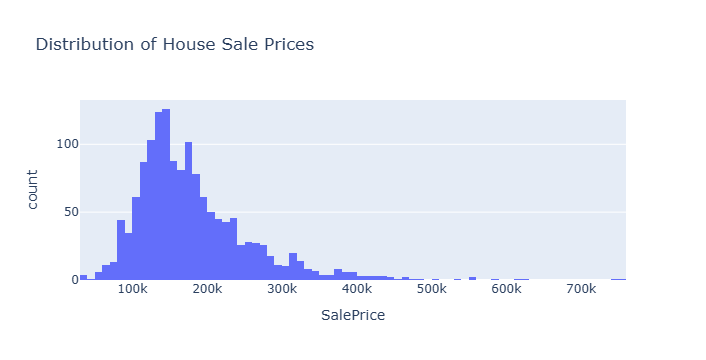

In [2]:
import plotly.express as px

fig = px.histogram(df, x='SalePrice', title='Distribution of House Sale Prices')
fig.show()

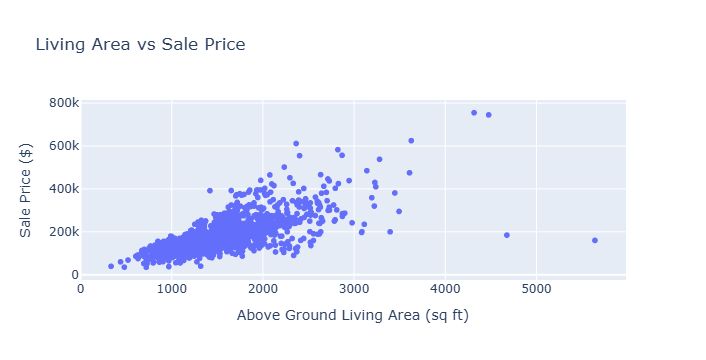

In [3]:
fig = px.scatter(
    df, 
    x='GrLivArea', 
    y='SalePrice',
    title='Living Area vs Sale Price',
    labels={'GrLivArea': 'Above Ground Living Area (sq ft)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()

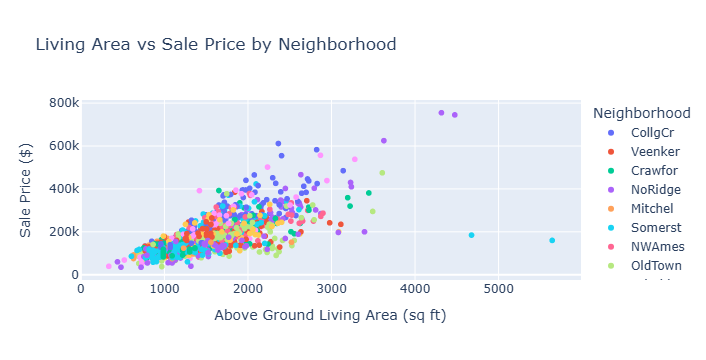

In [4]:
fig = px.scatter(
    df,
    x='GrLivArea',
    y='SalePrice',
    color='Neighborhood',
    title='Living Area vs Sale Price by Neighborhood',
    labels={'GrLivArea': 'Above Ground Living Area (sq ft)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()

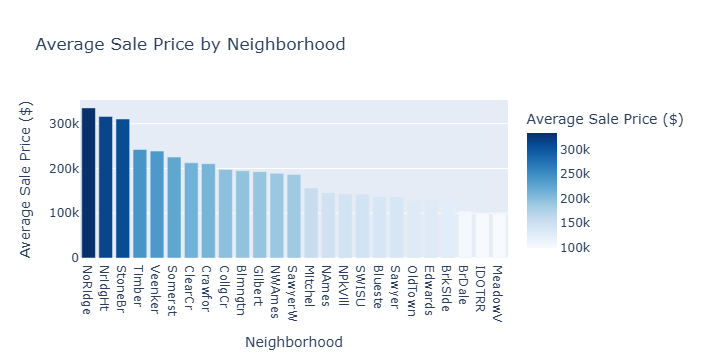

In [5]:
avg_price = df.groupby('Neighborhood')['SalePrice'].mean().reset_index()
avg_price = avg_price.sort_values('SalePrice', ascending=False)

fig = px.bar(
    avg_price,
    x='Neighborhood',
    y='SalePrice',
    title='Average Sale Price by Neighborhood',
    labels={'SalePrice': 'Average Sale Price ($)'},
    color='SalePrice',
    color_continuous_scale='Blues'
)
fig.show()

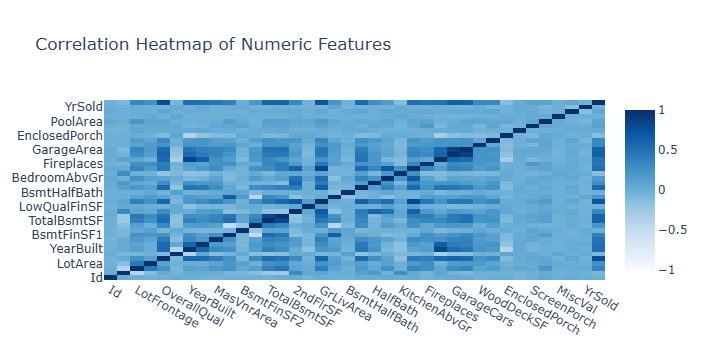

In [6]:
import plotly.graph_objects as go

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr().round(2)

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.columns,
    colorscale='Blues',
    zmin=-1,
    zmax=1
))

fig.update_layout(title='Correlation Heatmap of Numeric Features')
fig.show()

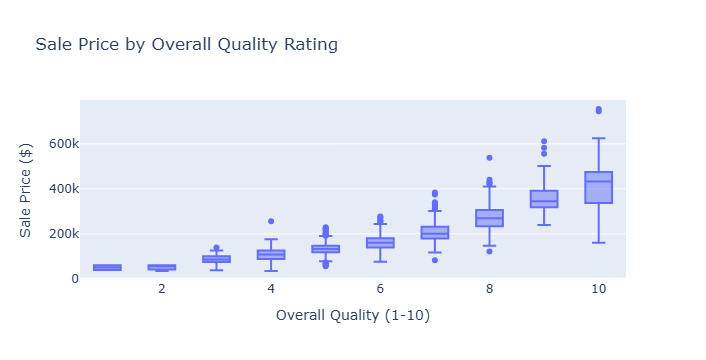

In [7]:
fig = px.box(
    df,
    x='OverallQual',
    y='SalePrice',
    title='Sale Price by Overall Quality Rating',
    labels={'OverallQual': 'Overall Quality (1-10)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()

3 Business Insights discovered:

NridgHt, NoRidge, StoneBr are the most expensive neighbourhoods

Larger living area = higher price

OverallQual, GrLivArea, GarageCars are the strongest price predictors



In [8]:
pip install sweetviz

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html('house_prices_report.html')

C:\Users\Owner\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |█| [100%]   00:06 -> (00:00 l


Report house_prices_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [10]:
cols = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

df[cols] = df[cols].fillna("None")
df[cols].isnull().sum()

PoolQC          0
Alley           0
Fence           0
FireplaceQu     0
MasVnrType      0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

In [11]:
cols = ['MasVnrArea', 'GarageYrBlt']
df[cols] = df[cols].fillna(0)
df[cols].isnull().sum()

MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [12]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [13]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['MiscFeature'] = df['MiscFeature'].fillna("None")
df['Electrical'].isnull().sum()
df['LotFrontage'].isnull().sum()

np.int64(0)

In [14]:
df.isnull().sum().sum() 
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [15]:
df.to_csv('house_prices_cleaned.csv', index=False)

In [16]:
df = pd.read_csv('house_prices_cleaned.csv')
print(df.shape)

(1460, 81)


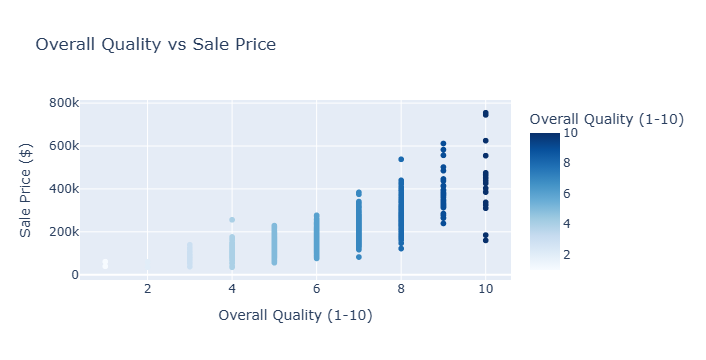

In [17]:
fig = px.scatter(
    df,
    x='OverallQual',
    y='SalePrice',
    color='OverallQual',
    title='Overall Quality vs Sale Price',
    labels={'OverallQual': 'Overall Quality (1-10)', 'SalePrice': 'Sale Price ($)'},
    color_continuous_scale='Blues'
)
fig.show()


The overall quality has a positive correlation with sale price, and also there is a wider range  in sale price as overall quality increases.

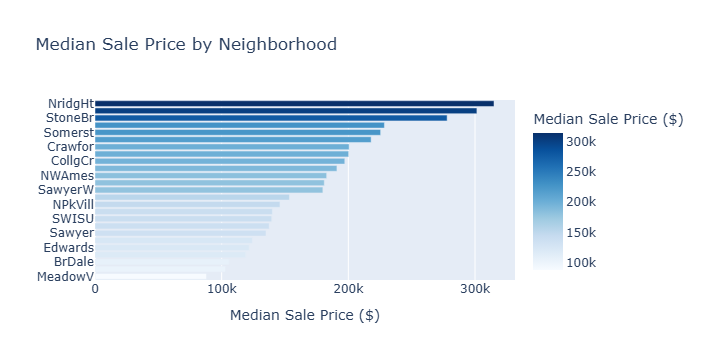

In [18]:
avg_by_neighborhood = df.groupby('Neighborhood')['SalePrice'].median().reset_index()
avg_by_neighborhood = avg_by_neighborhood.sort_values('SalePrice', ascending=True)

fig = px.bar(
    avg_by_neighborhood,
    x='SalePrice',
    y='Neighborhood',
    orientation='h',
    title='Median Sale Price by Neighborhood',
    labels={'SalePrice': 'Median Sale Price ($)', 'Neighborhood': ''},
    color='SalePrice',
    color_continuous_scale='Blues'
)
fig.show()

Location is a major price driver — NridgHt median price (\$315k) is 3.5x higher than MeadowV (\$88k), showing neighbourhood alone can account for over \$227k difference in house price.

In [19]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

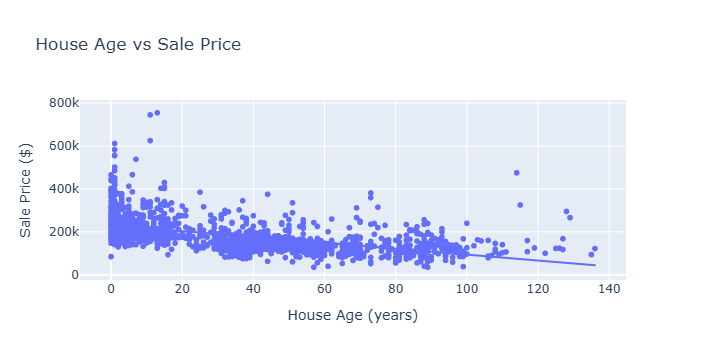

In [20]:

fig = px.scatter(
    df,
    x='HouseAge',
    y='SalePrice',
    title='House Age vs Sale Price',
    labels={'HouseAge': 'House Age (years)', 'SalePrice': 'Sale Price ($)'},
    trendline='ols'
)
fig.show()

ewer houses command higher prices — sale price shows a negative correlation with house age, suggesting buyers pay a premium for modern construction.

## Project 1 — Final Visualisations

In [21]:
df = pd.read_csv("house_prices_cleaned.csv")

In [22]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


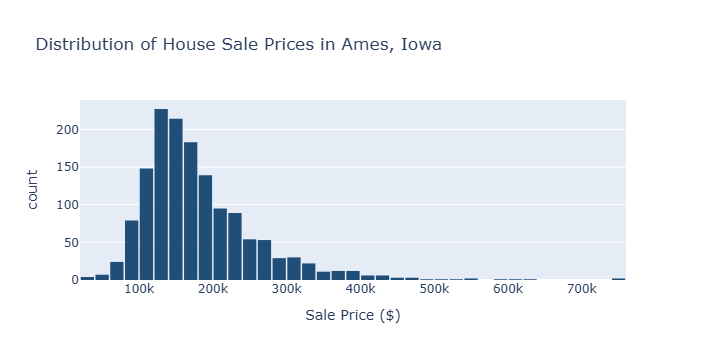

In [23]:
import plotly.express as px

fig = px.histogram(
    df,
    x='SalePrice',
    nbins=50,
    title='Distribution of House Sale Prices in Ames, Iowa',
    labels={'SalePrice': 'Sale Price ($)', 'count': 'Number of Houses'},
    color_discrete_sequence=['#1F4E79']
)
fig.update_layout(bargap=0.1)
fig.show()


Most houses in Ames sell between 100k-300k, with the distribution peaking around 150k and a long right tail indicating a small number of luxury properties above 400k.

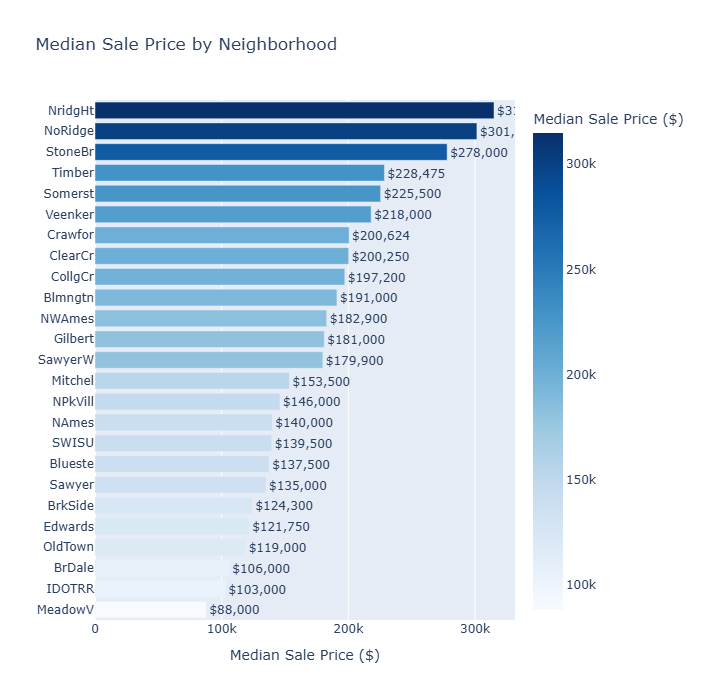

In [24]:
avg_price = df.groupby('Neighborhood')['SalePrice'].median().reset_index()
avg_price = avg_price.sort_values('SalePrice', ascending=True)

fig = px.bar(
    avg_price,
    x='SalePrice',
    y='Neighborhood',
    orientation='h',
    title='Median Sale Price by Neighborhood',
    labels={'SalePrice': 'Median Sale Price ($)', 'Neighborhood': ''},
    color='SalePrice',
    color_continuous_scale='Blues',
    text='SalePrice'
)
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(height=700)
fig.show()

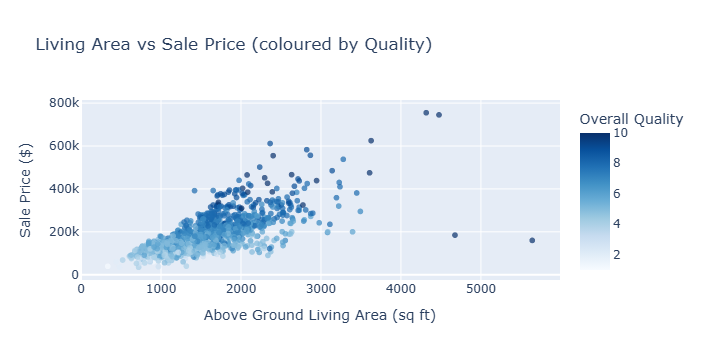

In [25]:
fig = px.scatter(
    df,
    x='GrLivArea',
    y='SalePrice',
    color='OverallQual',
    title='Living Area vs Sale Price (coloured by Quality)',
    labels={
        'GrLivArea': 'Above Ground Living Area (sq ft)',
        'SalePrice': 'Sale Price ($)',
        'OverallQual': 'Overall Quality'
    },
    color_continuous_scale='Blues',
    opacity=0.7
)
fig.show()

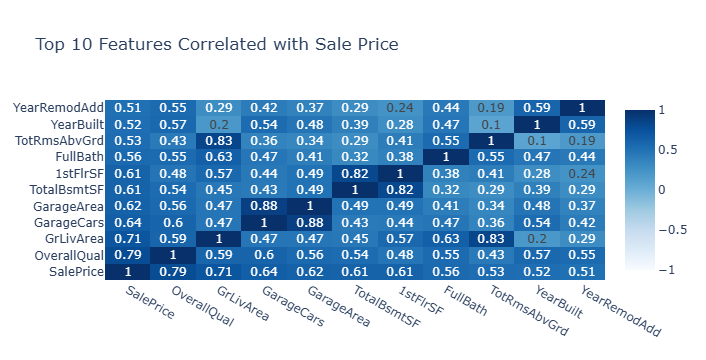

In [26]:
import plotly.graph_objects as go

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

# Get top 10 features most correlated with SalePrice
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(11).index
corr_top = corr.loc[top_features, top_features].round(2)

fig = go.Figure(data=go.Heatmap(
    z=corr_top.values,
    x=corr_top.columns,
    y=corr_top.columns,
    colorscale='Blues',
    text=corr_top.values,
    texttemplate='%{text}',
    zmin=-1,
    zmax=1
))

fig.update_layout(title='Top 10 Features Correlated with Sale Price')
fig.show()

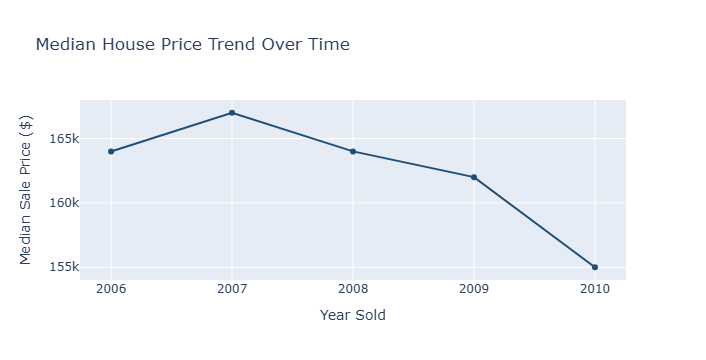

In [27]:
price_by_year = df.groupby('YrSold')['SalePrice'].median().reset_index()

fig = px.line(
    price_by_year,
    x='YrSold',
    y='SalePrice',
    title='Median House Price Trend Over Time',
    labels={'YrSold': 'Year Sold', 'SalePrice': 'Median Sale Price ($)'},
    markers=True,
    color_discrete_sequence=['#1F4E79']
)
fig.show()